# <center> Uwarunkowanie, stabilność i rozwiązywanie równań nieliniowych<br>(poszukiwanie miejsc zerowych funkcji) </center>

# Uwarunkowanie i stabilność


***Zadanie 1. Czy wyznaczanie miejsc zerowych wielomianu może być zadaniem dobrze/źle uwarunkowanym? (Wielomian Wilkinsona)***

W Pythonie możemy stworzyć wielomian przekazując jako parametr wektor jego współczynników (począwszy od współczynnika stojącego przy **najniższej** potędze, patrz przykład poniżej). Proszę korzystać z modułu *numpy.polynomial* (zamiast *poly1d*).
* Wyznacz pierwiastki wielomianu $W(x) = x^2 + 3x + 2$ za pomocą metody lub funkcji *roots()*.
* Funkcja *Polynomial.fromroots* tworzy wielomian na podstawie listy przekazanych pierwiastków. Utwórz wielomian o następujących pierwiastkach $\{x_n = n, n = 1, 2, 3, . . . , 15\}$.
* Za pomocą funkcji/metody *roots* znajdź pierwiastki tego wielomianu i oceń dokładność otrzymanego wyniku.
* Do trzynastego elementu wektora współczynników wprowadź małe zaburzenie (np. rzędu $10^−5$) i znajdź pierwiastki wielomianu o zaburzonych współczynnikach. Wykreśl pierwiastki na płaszczyznie zespolonej. 
* Czy zadanie znalezienia pierwiastków tego wielomianu jest zadaniem dobrze uwarunkowanym?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from numpy.polynomial import Polynomial
# Przykłady operacji na wielomianach
p = Polynomial([3, 2, 1]) # Od ostatniego współczynnika
print(p)
print(p.roots())
print(Polynomial.roots(p))




Pierwiastki x^2 + 3x + 2: [-2. -1.]
Błąd wyznaczenia pierwiastków (max): 7.96796097723984e-06


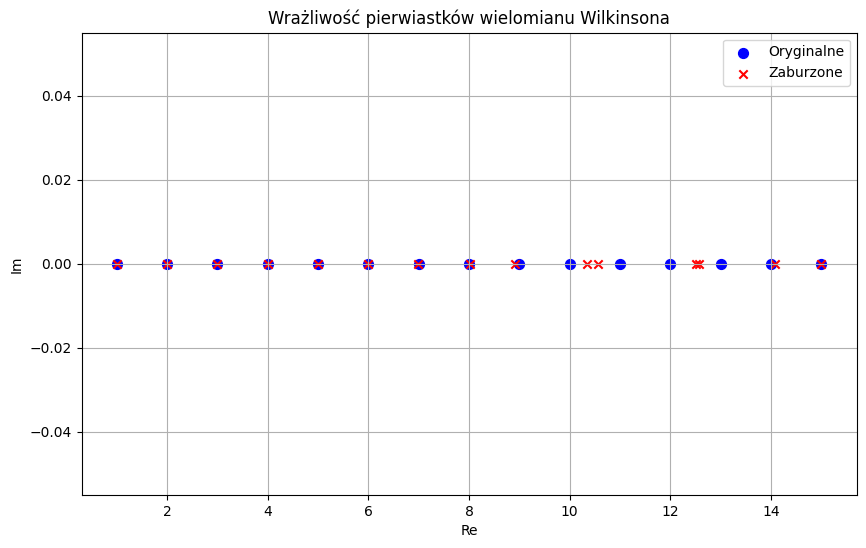

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

p1 = Polynomial([2, 3, 1])  
print(f"Pierwiastki x^2 + 3x + 2: {p1.roots()}")

roots_orig = np.arange(1, 16)
p_wilkinson = Polynomial.fromroots(roots_orig)

found_roots = p_wilkinson.roots()
print(f"Błąd wyznaczenia pierwiastków (max): {np.max(np.abs(found_roots - roots_orig))}")

coeffs_perturbed = p_wilkinson.coef.copy()
coeffs_perturbed[12] += 1e-5 
p_perturbed = Polynomial(coeffs_perturbed)
roots_perturbed = p_perturbed.roots()

plt.figure(figsize=(10, 6))
plt.scatter(roots_orig, np.zeros_like(roots_orig), color='blue', label='Oryginalne', s=50)
plt.scatter(roots_perturbed.real, roots_perturbed.imag, color='red', marker='x', label='Zaburzone')
plt.title("Wrażliwość pierwiastków wielomianu Wilkinsona")
plt.xlabel("Re")
plt.ylabel("Im")
plt.legend()
plt.grid(True)
plt.show()

***Zadanie 2. Całka oznaczona***

Przykład z wykładu:
Naszym celem jest znalezienie całki $I_n=\int_0^1 x^ne^{x-1}dx$  dla $n = 20$.
* Na podstawie np. przybliżonych wykresów funkcji podcałkowej, proszę oszacować wartość tej całki oraz relację miedzy $I_n$ a $I_{n−1}$.
* Ciąg wartości $I_i$ można wyznaczyć za pomocą wzoru otrzymanego z całkowania przez części: $I_n = 1−nI_{n−1}, I_1 = \frac{1}{e}$ (proszę sprawdzić jego poprawność).
* Czy otrzymane wyniki są zgodne z przewidywaniami? Która operacja może powodować takie skutki?
* Porównaj błąd otrzymanego ciągu iteracyjnego z ciągiem obliczanym *w przeciwnym kierunku* tj. od $I_{20}$ do $I_1$. Proszę przyjąć, że $I_{20} = 0$.
* Jak duży jest błąd danej wejściowej ($I_{20}$) i ostatniego elementu ciągu ($I_1$)?
* Który algorytm jest stabilny, a który niestabilny?

In [6]:
def forward_integration(n_max):
    I = np.zeros(n_max + 1)
    I[1] = 1 - 1/np.exp(1) 
    for n in range(2, n_max + 1):
        I[n] = 1 - n * I[n-1]
    return I

def backward_integration(n_start, n_target):
    I = np.zeros(n_start + 1)
    I[n_start] = 0 
    for n in range(n_start, n_target, -1):
        I[n-1] = (1 - I[n]) / n
    return I

n = 20
forward_results = forward_integration(n)
backward_results = backward_integration(n, 1)

print(f"Rekurencja w przód (I_20): {forward_results[20]}")
print(f"Rekurencja w tył (I_1): {backward_results[1]}")

Rekurencja w przód (I_20): -6.428727457908358e+17
Rekurencja w tył (I_1): 0.36787944117144233


# Poszukiwanie miejsc zerowych

Dana jest funkcja $$f(x) = e^{-2x}+x^2-1$$

***Zadanie 1.***

Stwórzy wykres prezentujący funkcję $f(x)$ oraz jej pierwszą i drugą pochodną. Na podstawie spróbuj oszacować wartości pierwiastków równania $f(x) = 0$.

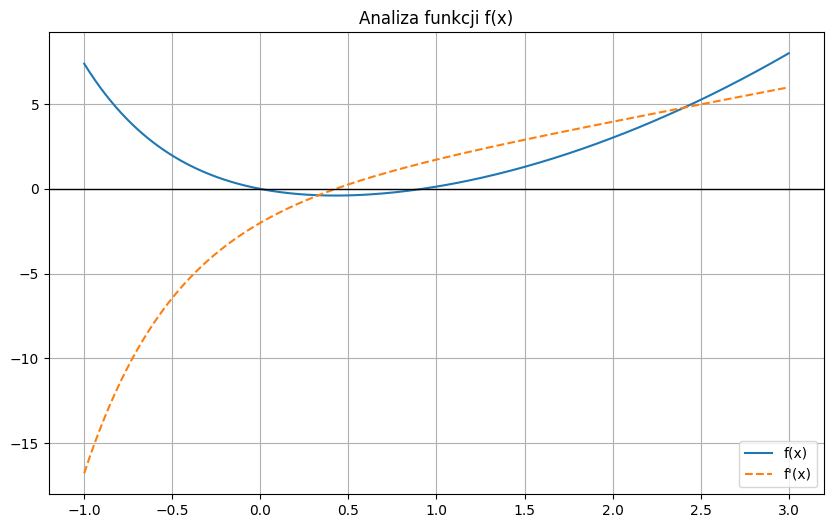

In [3]:
f = lambda x: np.exp(-2*x) + x**2 - 1
df = lambda x: -2*np.exp(-2*x) + 2*x
ddf = lambda x: 4*np.exp(-2*x) + 2

x_val = np.linspace(-1, 3, 400)
plt.figure(figsize=(10, 6))
plt.plot(x_val, f(x_val), label='f(x)')
plt.plot(x_val, df(x_val), '--', label="f'(x)")
plt.axhline(0, color='black', lw=1)
plt.title("Analiza funkcji f(x)")
plt.legend()
plt.grid(True)
plt.show()

***Zadanie 2.***

Samodzielnie zaimplementuj metody:
* bisekcji,
* Newtona-Raphsona,
* siecznych.

Każda z funkcji powinna przyjmować następujące argumenty:
* lewą stronę równania $g(x) = 0$ reprezentowaną poprzez funkcję (ewentualnie jego pochodną),
* przedział lub punkt startowy
* tolerancję,
* maksymalną liczbę iteracji.

i zwracać:
* znaleziony pierwiastek,
* liczbę iteracji.

W jaki sposób sprawdzić warunek stopu? Czy kryterium stopu polegające na kontynuacji iteracji dopóki $x_{i+1}\neq x_i$ jest prawidłowe (bezpieczne)?

In [5]:
def bisection(f, a, b, tol, max_iter):
    if f(a) * f(b) > 0:
        return None, 0
    for i in range(max_iter):
        c = (a + b) / 2
        if abs(f(c)) < tol or (b - a) / 2 < tol:
            return c, i + 1
        if f(c) * f(a) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2, max_iter


def newton(f, df, x0, tol, max_iter):
    x = x0
    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)
        if abs(dfx) < 1e-12: break 
        x_new = x - fx / dfx
        if abs(x_new - x) < tol:
            return x_new, i + 1
        x = x_new
    return x, max_iter

def secant(f, x0, x1, tol, max_iter):
    for i in range(max_iter):
        fx0 = f(x0)
        fx1 = f(x1)
        if abs(fx1 - fx0) < 1e-12: break
        x_new = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        if abs(x_new - x1) < tol:
            return x_new, i + 1
        x0, x1 = x1, x_new
    return x1, max_iter

***Zadanie 3.***

Wykorzystaj stworzone w zadaniu 2. metody do znalezienia miejsc zerowych funkcji $f(x)$ z dokładnością $\epsilon = 10^{-6}$. Porównaj liczby iteracji niezbędnych do znalezienia pierwiastka. Która metoda sprawdziła się najlepiej? Która wypada najgorzej? Czy odpowiedni dobór przedziału może przyspieszyć proces rozwiązywania? Eksperyment przeprowadź dla wszystkich miejsc zerowych $f(x)$.


In [18]:
epsilon = 1e-6
root_bis, it_bis = bisection(f, 0.5, 1.5, epsilon, 100)
root_newt, it_newt = newton(f, df, 1.5, epsilon, 100)
root_sec, it_sec = secant(f, 0.5, 1.5, epsilon, 100)

print(f"Metoda bisekcji: pierwiastek = {root_bis:.6f}, iteracje = {it_bis}")
print(f"Metoda Newtona:  pierwiastek = {root_newt:.6f}, iteracje = {it_newt}")
print(f"Metoda siecznych: pierwiastek = {root_sec:.6f}, iteracje = {it_sec}")

Metoda bisekcji: pierwiastek = 0.916563, iteracje = 19
Metoda Newtona:  pierwiastek = 0.916563, iteracje = 5
Metoda siecznych: pierwiastek = 0.916563, iteracje = 7


***Zadanie 4.***

Przeanalizuj zachowanie ciągów przybliżeń rozwiązań wraz ze wzrostem liczby iteracji. Przedstaw wyniki w postaci wykresu i dokonaj ich analizy.

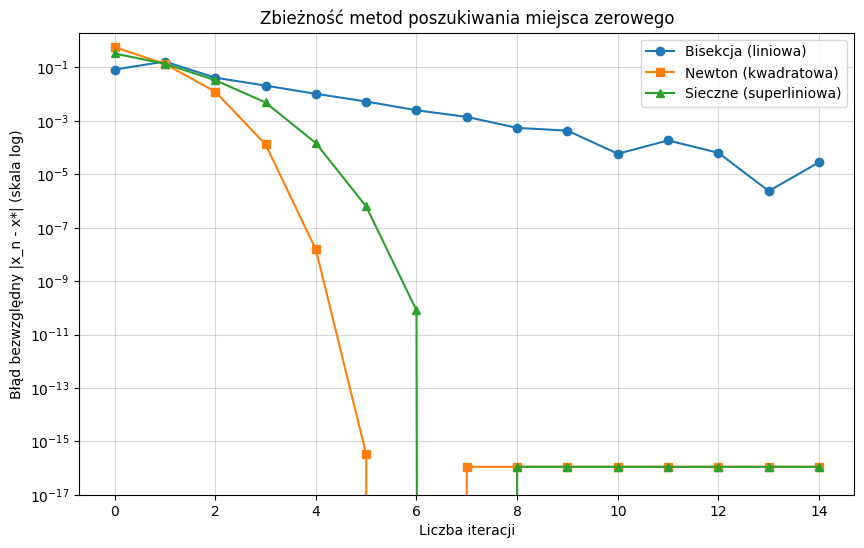

In [16]:
import numpy as np
import matplotlib.pyplot as plt
f = lambda x: np.exp(-2*x) + x**2 - 1
df = lambda x: -2*np.exp(-2*x) + 2*x
true_root = 0.9165625831056981 
def get_errors_bisection(a, b, iters):
    errors = []
    for _ in range(iters):
        c = (a + b) / 2
        errors.append(abs(c - true_root))
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return errors

def get_errors_newton(x0, iters):
    errors = []
    x = x0
    for _ in range(iters):
        errors.append(abs(x - true_root))
        x = x - f(x) / df(x)
    return errors

def get_errors_secant(x0, x1, iters):
    errors = []
    for _ in range(iters):
        errors.append(abs(x1 - true_root))
        f0, f1 = f(x0), f(x1)
        if abs(f1 - f0) < 1e-16: 
            x_new = x1
        else:
            x_new = x1 - f1 * (x1 - x0) / (f1 - f0)
        x0, x1 = x1, x_new
    return errors
N_ITERS = 15
err_bis = get_errors_bisection(0.5, 1.5, N_ITERS) # Start: c=1.0, błąd ~0.08
err_new = get_errors_newton(1.5, N_ITERS)         # Start: x=1.5, błąd ~0.58
err_sec = get_errors_secant(0.5, 1.25, N_ITERS)   # Start: x1=1.25, błąd ~0.33
plt.figure(figsize=(10, 6))
plt.semilogy(err_bis, 'o-', label='Bisekcja (liniowa)')
plt.semilogy(err_new, 's-', label='Newton (kwadratowa)')
plt.semilogy(err_sec, '^-', label='Sieczne (superliniowa)')
plt.title('Zbieżność metod poszukiwania miejsca zerowego')
plt.xlabel('Liczba iteracji')
plt.ylabel('Błąd bezwzględny |x_n - x*| (skala log)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.ylim(1e-17, 2)
plt.show()